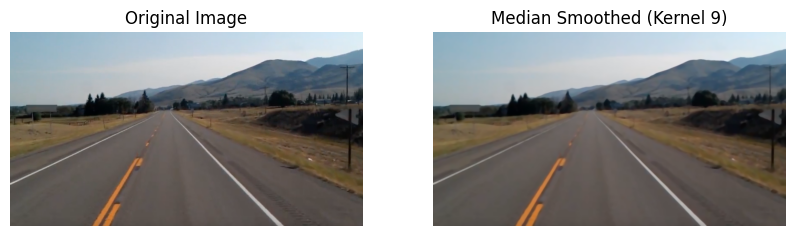

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. Load the image
image_path = os.path.join('assets', 'lane.jpg')
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Apply Median Smoothing
kernel_size = 9
smoothed_image = cv2.medianBlur(image_rgb, kernel_size)

# 3. Display the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Median Smoothed (Kernel {kernel_size})")
plt.imshow(smoothed_image)
plt.axis('off')

plt.show()

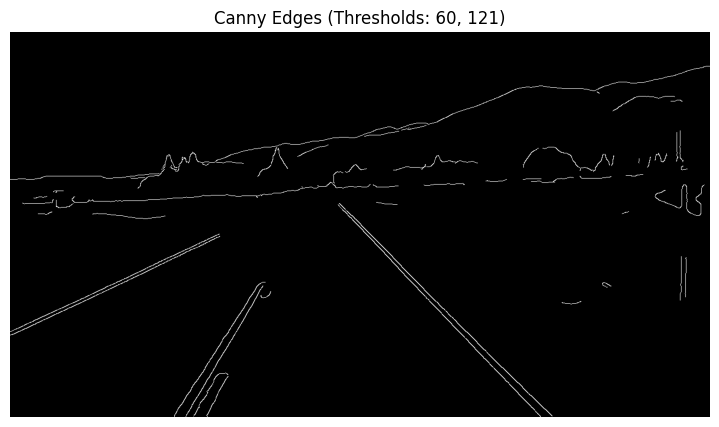

In [39]:
# 1. Convert to Grayscale 
gray_smoothed = cv2.cvtColor(smoothed_image, cv2.COLOR_RGB2GRAY)

# 2. Apply Canny Edge Detection (Median Approach)
v = np.median(gray_smoothed)
sigma = 0.33  # 33% variation
low_threshold = int(max(0, (1.0 - sigma) * v))
high_threshold = int(min(255, (1.0 + sigma) * v))

edges = cv2.Canny(gray_smoothed, low_threshold, high_threshold)

# 3. Display the result
plt.figure(figsize=(10, 5))
plt.imshow(edges, cmap='gray')
plt.title(f"Canny Edges (Thresholds: {low_threshold}, {high_threshold})")
plt.axis('off')
plt.show()

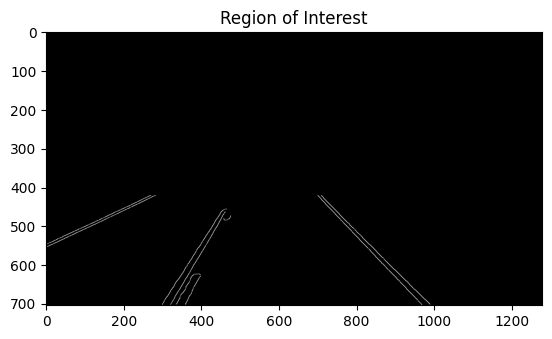

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def region_of_interest(img):
    height, width = img.shape
    
    # Define a trapezoid using percentages
    # (x, y) coordinates
    bottom_left  = (width * 0.0, height)        # Near bottom-left corner
    bottom_right = (width * 0.95, height)       # Near bottom-right corner
    top_right    = (width * 0.65, height * 0.6) # Right side of the horizon
    top_left     = (width * 0.0, height * 0.6)  # Shifted far left to catch the left lane
    
    vertices = np.array([[bottom_left, bottom_right, top_right, top_left]], dtype=np.int32)
    
    # Create the mask
    mask = np.zeros_like(img)
    cv2.fillPoly(mask, vertices, 255)
    
    # Apply the mask
    masked_img = cv2.bitwise_and(img, mask)
    return masked_img

# Apply to your edge-detected image
wide_road_edges = region_of_interest(edges)

plt.imshow(wide_road_edges, cmap='gray')
plt.title("Region of Interest")
plt.show()

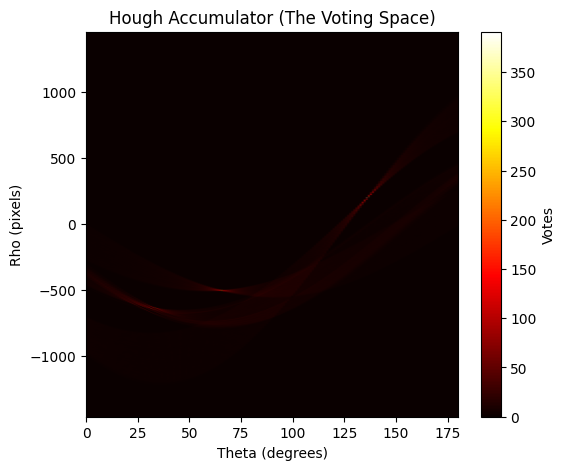

In [ ]:


def hough_transform(edge_img):
    # 1. Define the Accumulator dimensions
    height, width = edge_img.shape
    diag_len = int(np.sqrt(height**2 + width**2)) # Max possible rho
    rhos = np.linspace(-diag_len, diag_len, diag_len * 2)
    thetas = np.deg2rad(np.arange(0, 180))
    # Create the accumulator array (H)
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    
    # 2. Get coordinates of all edge pixels 
    y_idxs, x_idxs = np.nonzero(edge_img)
    
    # 3. Voting Operation 
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        
        for t_idx in range(len(thetas)):
            theta = thetas[t_idx]
            rho = x * np.cos(theta) + y * np.sin(theta)
            
            rho_idx = int(rho + diag_len) 
            accumulator[rho_idx, t_idx] += 1
            
    return accumulator, thetas, rhos

accumulator, thetas, rhos = hough_transform(wide_road_edges)

# 4. Plot the Accumulator Array
plt.figure(figsize=(6, 5))
plt.imshow(accumulator, cmap='hot', extent=[0, 180, -len(rhos)//2, len(rhos)//2], aspect='auto')
plt.title("Hough Accumulator (The Voting Space)")
plt.xlabel("Theta (degrees)")
plt.ylabel("Rho (pixels)")
plt.colorbar(label='Votes')
plt.show()

In [ ]:
def find_hough_peaks(accumulator, thetas, rhos, num_peaks=10, threshold=100, neighborhood_size=20):
    
    peaks = []
    # Copy accumulator to avoid modifying the original during suppression
    acc_copy = np.copy(accumulator)
    
    for _ in range(num_peaks):
        # 1. Find the global maximum in the accumulator
        idx = np.argmax(acc_copy) 
        rho_idx, theta_idx = np.unravel_index(idx, acc_copy.shape)
        
        # 2. Check if the peak is strong enough
        if acc_copy[rho_idx, theta_idx] >= threshold:
            peaks.append((rhos[rho_idx], thetas[theta_idx]))
            
            # 3. Non-Maximum Suppression
            r_start = max(0, rho_idx - neighborhood_size)
            r_end = min(acc_copy.shape[0], rho_idx + neighborhood_size)
            t_start = max(0, theta_idx - neighborhood_size)
            t_end = min(acc_copy.shape[1], theta_idx + neighborhood_size)
            
            acc_copy[r_start:r_end, t_start:t_end] = 0
        else:
            break 
            
    return peaks

detected_lines = find_hough_peaks(accumulator, thetas, rhos, num_peaks=4, threshold=120)

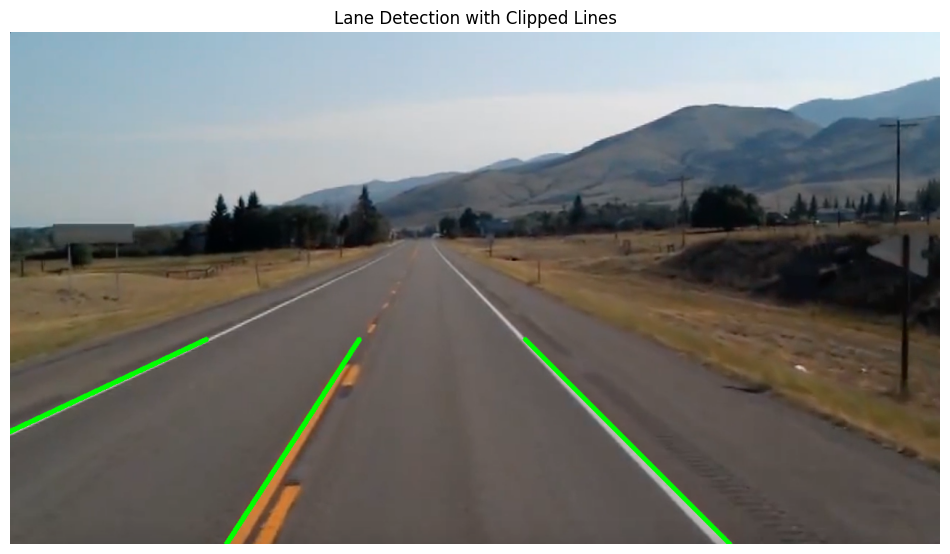

In [ ]:
def draw_clipped_lines(img, peaks, y_min, y_max):
    line_img = np.copy(img)
    
    for rho, theta in peaks:
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        
        # Avoid division by zero for horizontal lines
        if cos_t == 0: continue 
        
        # Calculate x coordinates at the bottom (y_max) and top (y_min) of the ROI
        x_bottom = int((rho - y_max * sin_t) / cos_t)
        x_top = int((rho - y_min * sin_t) / cos_t)
        
        # Draw only the segment within the vertical road boundaries
        cv2.line(line_img, (x_top, y_min), (x_bottom, y_max), (0, 255, 0), 5)
        
    return line_img

# y_max is the bottom of the image
y_max = image_rgb.shape[0]
# y_min is the 'horizon' line from ROI step
y_min = int(y_max * 0.6) 

final_clipped_result = draw_clipped_lines(image_rgb, detected_lines, y_min, y_max)

plt.figure(figsize=(12, 8))
plt.imshow(final_clipped_result)
plt.title("Lane Detection with Clipped Lines")
plt.axis('off')
plt.show()